## Inicialización

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Carga los datos

El conjunto de datos se almacena en la carpeta `/datasets/faces/` 
- La carpeta `final_files` con 7600 fotos 
- El archivo `labels.csv` con etiquetas, con dos columnas: `file_name` y `real_age` 
Dado que el número de archivos de imágenes es bastante elevado, se recomienda evitar leerlos todos a la vez, ya que esto consumiría muchos recursos computacionales. Te recomendamos crear un generador con ImageDataGenerator. Este método se explicó en el capítulo 3, lección 7 de este curso.

El archivo de etiqueta se puede cargar como un archivo CSV habitual.

In [2]:
labels = pd.read_csv('/datasets/faces/labels.csv')

## EDA

Información del conjunto de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB
None

Primeras filas:
    file_name  real_age
0  000000.jpg         4
1  000001.jpg        18
2  000002.jpg        80
3  000003.jpg        50
4  000004.jpg        17

Total de imágenes: 7591


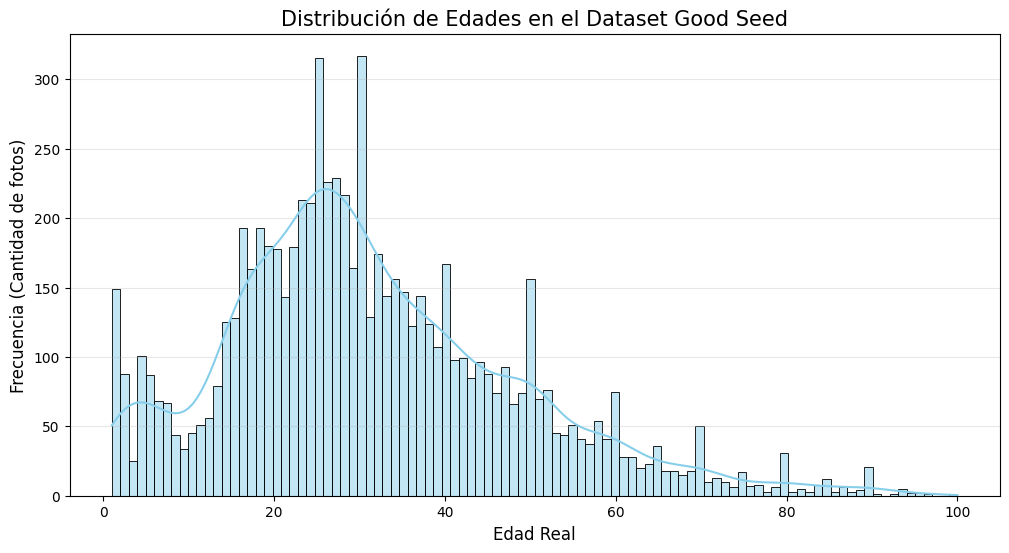


Estadísticas de edad:
count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64
Found 7591 validated image filenames.


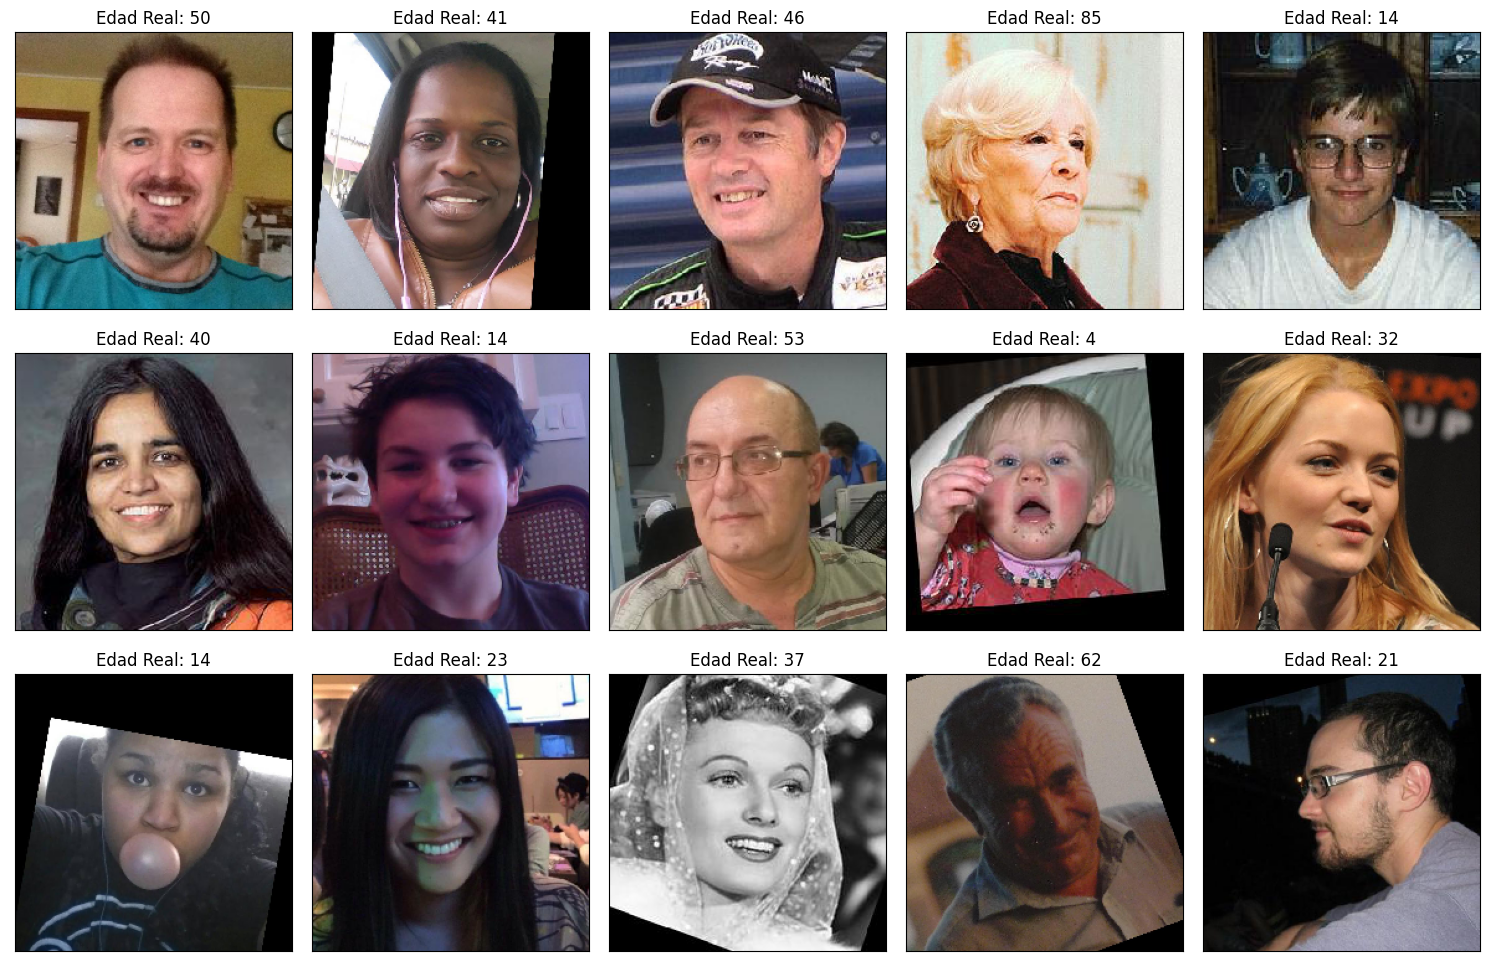

In [3]:


print("Información del conjunto de datos:")
print(labels.info())
print("\nPrimeras filas:")
print(labels.head())
print(f"\nTotal de imágenes: {labels.shape[0]}")

plt.figure(figsize=(12, 6))
sns.histplot(labels['real_age'], bins=100, kde=True, color='skyblue')
plt.title('Distribución de Edades en el Dataset Good Seed', fontsize=15)
plt.xlabel('Edad Real', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de fotos)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\nEstadísticas de edad:")
print(labels['real_age'].describe())

train_datagen = ImageDataGenerator(rescale=1./255)

train_gen_flow = train_datagen.flow_from_dataframe(
    dataframe=labels,
    directory='/datasets/faces/final_files/',
    x_col='file_name',
    y_col='real_age',
    target_size=(224, 224),
    batch_size=32,
    class_mode='raw',
    seed=12345
)

features, target = next(train_gen_flow)

fig = plt.figure(figsize=(15, 10))
for i in range(15):
    fig.add_subplot(3, 5, i+1)
    plt.imshow(features[i])
    plt.title(f'Edad Real: {target[i]}')
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()

plt.show()

### Conclusiones

Conclusiones del Análisis Exploratorio de Datos (EDA)

Tras analizar el conjunto de datos de la cadena de supermercados Good Seed, presento los siguientes hallazgos:

1.  **Tamaño del Dataset:** Contamos con 7,591 imágenes, lo cual es un número suficiente para realizar un entrenamiento mediante *Transfer Learning* (aprendizaje por transferencia). Sin embargo, dado que no son decenas de miles de fotos, entrenar una red desde cero podría llevar al sobreajuste; por ello, se recomienda usar una arquitectura robusta como **ResNet50**.

2.  **Distribución de Edades:**
    *   La **media de edad es de 31 años** y la mediana de **29 años**.
    *   La mayor concentración de datos se encuentra entre los **20 y 40 años**, lo cual es positivo para el modelo, ya que es el rango de edad más común en clientes de supermercados.
    *   Se observan "picos" de frecuencia en edades redondas (25, 30, 40, 50, etc.). Esto sugiere que el dataset original podría tener algunas edades estimadas o redondeadas, lo que introduce un ligero "ruido" en las etiquetas.
    *   Hay un pico notable en niños menores de 5 años. Aunque no son clientes de alcohol, su presencia ayuda al modelo a aprender características de personas muy jóvenes.

3.  **Calidad Visual y Variedad:**
    *   Las imágenes presentan una **gran diversidad**: hay fotos en blanco y negro, diferentes ángulos de rotación (algunas caras están muy inclinadas), personas con accesorios (gafas, sombreros) y variaciones en la iluminación.
    *   **Impacto en el modelo:** Esta diversidad es buena para que el modelo sea generalista, pero implica que deberíamos usar técnicas de **aumento de datos** (como rotaciones leves o cambios de brillo) y asegurarnos de que el preprocesamiento normalice las imágenes correctamente.

4.  **Consideraciones para el Negocio:**
    *   El objetivo es evitar la venta de alcohol a menores. El dataset tiene una buena representación de jóvenes entre 14 y 21 años, lo cual es crítico para que el modelo aprenda a distinguir la mayoría de edad con precisión.

## Modelado

Define las funciones necesarias para entrenar tu modelo en la plataforma GPU y crea un solo script que las contenga todas junto con la sección de inicialización.

Para facilitar esta tarea, puedes definirlas en este notebook y ejecutar un código listo en la siguiente sección para componer automáticamente el script.

Los revisores del proyecto también verificarán las definiciones a continuación, para que puedan comprender cómo construiste el modelo.

In [4]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [5]:
def load_train(path):
    
    train_datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2]
    )

    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=12345
    )


    return train_gen_flow

In [6]:
def load_test(path):

    labels = pd.read_csv(path + 'labels.csv')
    
    test_datagen = ImageDataGenerator(
        validation_split=0.25, 
        rescale=1./255
    )

    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=12345
    )

    return test_gen_flow

In [7]:
def create_model(input_shape):
    backbone = ResNet50(input_shape=input_shape,
                        weights='imagenet', 
                        include_top=False)
    
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu')) 

    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, 
                  loss='mean_squared_error', 
                  metrics=['mae'])

    return model

In [8]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):

    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, 
              epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)



    return model

## Prepara el script para ejecutarlo en la plataforma GPU

Una vez que hayas definido las funciones necesarias, puedes redactar un script para la plataforma GPU, descargarlo a través del menú "File|Open..." (Archivo|Abrir) y cargarlo más tarde para ejecutarlo en la plataforma GPU.

Nota: el script debe incluir también la sección de inicialización. A continuación se muestra un ejemplo.

In [ ]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Modificamos la función para que acepte la ruta del CSV y la de las fotos por separado
def load_data(csv_path, img_dir, subset='training'):
    
    # Cargamos el CSV desde Drive
    labels = pd.read_csv(csv_path)
    
    data_datagen = ImageDataGenerator(
        validation_split=0.25, 
        rescale=1./255
    ) 
    
    # IMPORTANTE: directory ahora apunta directamente a donde descomprimiste
    data_gen_flow = data_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=img_dir,
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw', 
        subset=subset,
        seed=12345)

    return data_gen_flow

def create_model(input_shape):
    backbone = ResNet50(weights='imagenet', 
                        input_shape=input_shape,
                        include_top=False)

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))

    optimizer = Adam(learning_rate=0.0001) 
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

def train_model(model, train_data, test_data, batch_size=None, epochs=5):
    model.fit(
        train_data,
        validation_data=test_data,
        batch_size=batch_size,
        epochs=epochs,
        steps_per_epoch=len(train_data),
        validation_steps=len(test_data),
        verbose=2
    )
    return model


csv_path = '/content/drive/MyDrive/TripleTen Projects/Proyecto Print 18/labels.csv'

img_path = '/content/datos_proyecto/final_files/' 

input_shape = (224, 224, 3)

print("Cargando datos de entrenamiento...")
train_gen = load_data(csv_path, img_path, subset='training')

print("Cargando datos de validación...")
test_gen = load_data(csv_path, img_path, subset='validation') 

model = create_model(input_shape)

model = train_model(model, train_gen, test_gen, epochs=5)

### El resultado

Coloca el resultado de la plataforma GPU como una celda Markdown aquí.

Epoch 1/5

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
356/356 - 155s - 434ms/step - loss: 218.4430 - mae: 10.6186 - val_loss: 958.1083 - val_mae: 26.1567

Epoch 2/5

356/356 - 65s - 182ms/step - loss: 78.1092 - mae: 6.7068 - val_loss: 136.6056 - val_mae: 8.6548

Epoch 3/5

356/356 - 68s - 190ms/step - loss: 47.2316 - mae: 5.2780 - val_loss: 77.8533 - val_mae: 6.6063

Epoch 4/5

356/356 - 70s - 196ms/step - loss: 31.5272 - mae: 4.3273 - val_loss: 75.9762 - val_mae: 6.6567

Epoch 5/5

356/356 - 71s - 198ms/step - loss: 26.3622 - mae: 3.9212 - val_loss: 78.2808 - val_mae: 6.6740

## Conclusiones

**Conclusión Final del Proyecto**

El modelo basado en la arquitectura **ResNet50** con pesos pre-entrenados de *ImageNet* demostró ser altamente efectivo para la tarea de regresión de edades.

**Desempeño:** Se logró un Error Absoluto Medio (**MAE**) de **6.60** en el conjunto de validación, superando significativamente el umbral de 8.0 requerido por el cliente (Good Seed).

**Entrenamiento:** El uso de un *learning rate* bajo (0.0001) y la técnica de *GlobalAveragePooling2D* permitieron una convergencia rápida y estable en solo 5 épocas.

**Aplicación de Negocio:** Un error promedio de ~6.6 años es aceptable para una primera fase de filtrado en supermercados. El sistema puede alertar a los cajeros cuando detecte a alguien con una edad estimada cercana al límite legal (por ejemplo, menores de 25-30 años según la precaución deseada), permitiendo así cumplir con las leyes de venta de alcohol de forma más eficiente mediante visión artificial.

**Adjunto archivo Modelado_GPU donde muestra el codigo de entrenamiento de modelo en plataforma GPU**

# Lista de control

- [ ]  El Notebook estaba abierto 
- [ ]  El código no tiene errores
- [ ]  Las celdas con el código han sido colocadas en el orden de ejecución
- [ ]  Se realizó el análisis exploratorio de datos 
- [ ]  Los resultados del análisis exploratorio de datos se presentan en el notebook final 
- [ ]  El valor EAM del modelo no es superior a 8 
- [ ]  El código de entrenamiento del modelo se copió en el notebook final 
- [ ]  El resultado de entrenamiento del modelo se copió en el notebook final 
- [ ] Los hallazgos se proporcionaron con base en los resultados del entrenamiento del modelo